<a href="https://colab.research.google.com/github/ismethakanaydogmus/konya-agriculture-price-predictor/blob/main/Konya_Agriculture_EDA_and_Modeling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌾 Local Agricultural Price & Climate Predictor

**Konya Food and Agriculture University – Practical Data Science**

**Team Members:**
* [Öğrenci Numaran] İsmet Hakan Aydoğmuş

**Dataset:** Konya Wholesale Market Prices & Open-Meteo Climate Data – 5 Years (2021-2026)
**Target Variable:** `Fiyat_Degisim_Yuzdesi` (Supervised Regression - Percentage Price Change)

---
This notebook covers **Section 1 through Section 4** of the project presentation, including:

* Problem Formulation (Inflation Adjustment)
* Data Collection
* EDA (Schema Check, Statistics, Distributions, Relationships)
* Feature Engineering & Bug Investigation

In [19]:
# —— Global Imports & Settings ——
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Settings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
pd.set_option('display.max_columns', None)

print("✅ Libraries loaded successfully.")

✅ Libraries loaded successfully.


## Section 1 – Problem Formulation

### 1.1 Business Objective

Agricultural price volatility directly affects both farmers' livelihoods and consumers' purchasing power. Unpredictable weather events (such as sudden frosts, droughts, or heatwaves) play a massive role in crop yields, which in turn dictate market prices.

**Crucial Economic Adjustment:** Analyzing nominal wholesale prices in a high-inflation economy over a 5-year period results in non-stationary data (the model would learn macroeconomic inflation, not agricultural trends). To neutralize the inflation effect, we transformed the target variable from *Absolute Price (TL)* to **Daily Percentage Price Change (%)**.

Our goal is to build a system that predicts **by what percentage a crop's price will fluctuate** in the next market session based on historical price volatility and lagged climate data.

### 1.2 ML Problem Type

| Attribute | Value |
| :--- | :--- |
| **Problem Type** | Supervised Regression |
| **Target Variable** | `Fiyat_Degisim_Yuzdesi` (Continuous - Percentage) |
| **Unit of Observation** | One specific crop, on one calendar day (Mon/Thu) |

### 1.3 Success Metric

* **RMSE (Root Mean Squared Error):** Measures the average magnitude of the prediction error in percentage points.
* **MAE (Mean Absolute Error):** Provides the average absolute difference between predicted and actual percentage change.

## Section 2 – Data Collection

### 2.1 Data Source

Data was collected programmatically via web scraping and API requests for a 5-year period (Mar 2021 - Mar 2026):

| Source | What it provides | Method |
| :--- | :--- | :--- |
| **Konya Metropolitan Municipality** | Bi-weekly (Mon/Thu) lowest and highest wholesale prices | Python `BeautifulSoup` & `requests` |
| **Open-Meteo Archive API** | Daily maximum, minimum, mean temperatures, and precipitation sum | `archive-api.open-meteo.com` |

### 2.2 Collection Method (ETL Pipeline)

| Step | Decision | Reason |
| :--- | :--- | :--- |
| **Filtering Days** | Target only Mondays and Thursdays | The municipality only updates the market prices on these specific days. |
| **Merge weather** | `LEFT JOIN` on `Tarih` (Date) | Keep all price rows; append the corresponding daily climate data. |
| **Inflation Fix** | Create `Fiyat_Degisim_Yuzdesi` | Prevent the model from learning Turkey's macroeconomic inflation curve. |
| **Time-Series Lags** | `shift(7)`, `shift(14)`, `shift(30)` on climate data | Capture the delayed biological effect of weather on crop growth. |

In [20]:
# —— Load the final ML-ready dataset ——

df = pd.read_csv('/content/konya_tarim_final_engineered_dataset.csv')

# Convert Date column to datetime
df['Tarih'] = pd.to_datetime(df['Tarih'], format='%d.%m.%Y')

print(f"Dataset Shape: {df.shape[0]} rows × {df.shape[1]} columns")
display(df.head(3))

Dataset Shape: 23365 rows × 19 columns


,Tarih,Gün,Ürün Adı,Birim,En Düşük Fiyat,En Yüksek Fiyat,Onceki_Seans_En_Dusuk_Fiyat,Fiyat_Degisim_Yuzdesi,Maks_Sicaklik_C,Min_Sicaklik_C,Ort_Sicaklik_C,Toplam_Yagis_mm,Ort_Sicaklik_C_7_gun_once,Ort_Sicaklik_C_14_gun_once,Ort_Sicaklik_C_30_gun_once,Toplam_Yagis_mm_7_gun_once,Toplam_Yagis_mm_14_gun_once,Toplam_Yagis_mm_30_gun_once,Son_30_Gun_Ort_Yagis
0,2024-08-12,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,29.9,18.3,24.1,0.0,27.8,23.2,25.7,0.0,0.0,0.2,0.193333
1,2024-08-15,Perşembe,ACUR,Kg,15.0,25,15.0,0.0,32.9,19.6,26.3,0.0,26.8,24.3,26.2,0.0,0.0,0.0,0.193333
2,2024-08-19,Pazartesi,ACUR,Kg,15.0,25,15.0,0.0,35.5,17.3,26.7,0.0,24.1,27.8,26.7,0.0,0.0,0.0,0.106667


### Section 3.3 – Distributions

**Target Variable Distribution:** By converting absolute prices to percentage changes, we expect a stationary, normally distributed target centered around 0% (indicating price stability most days, with rare extreme spikes).

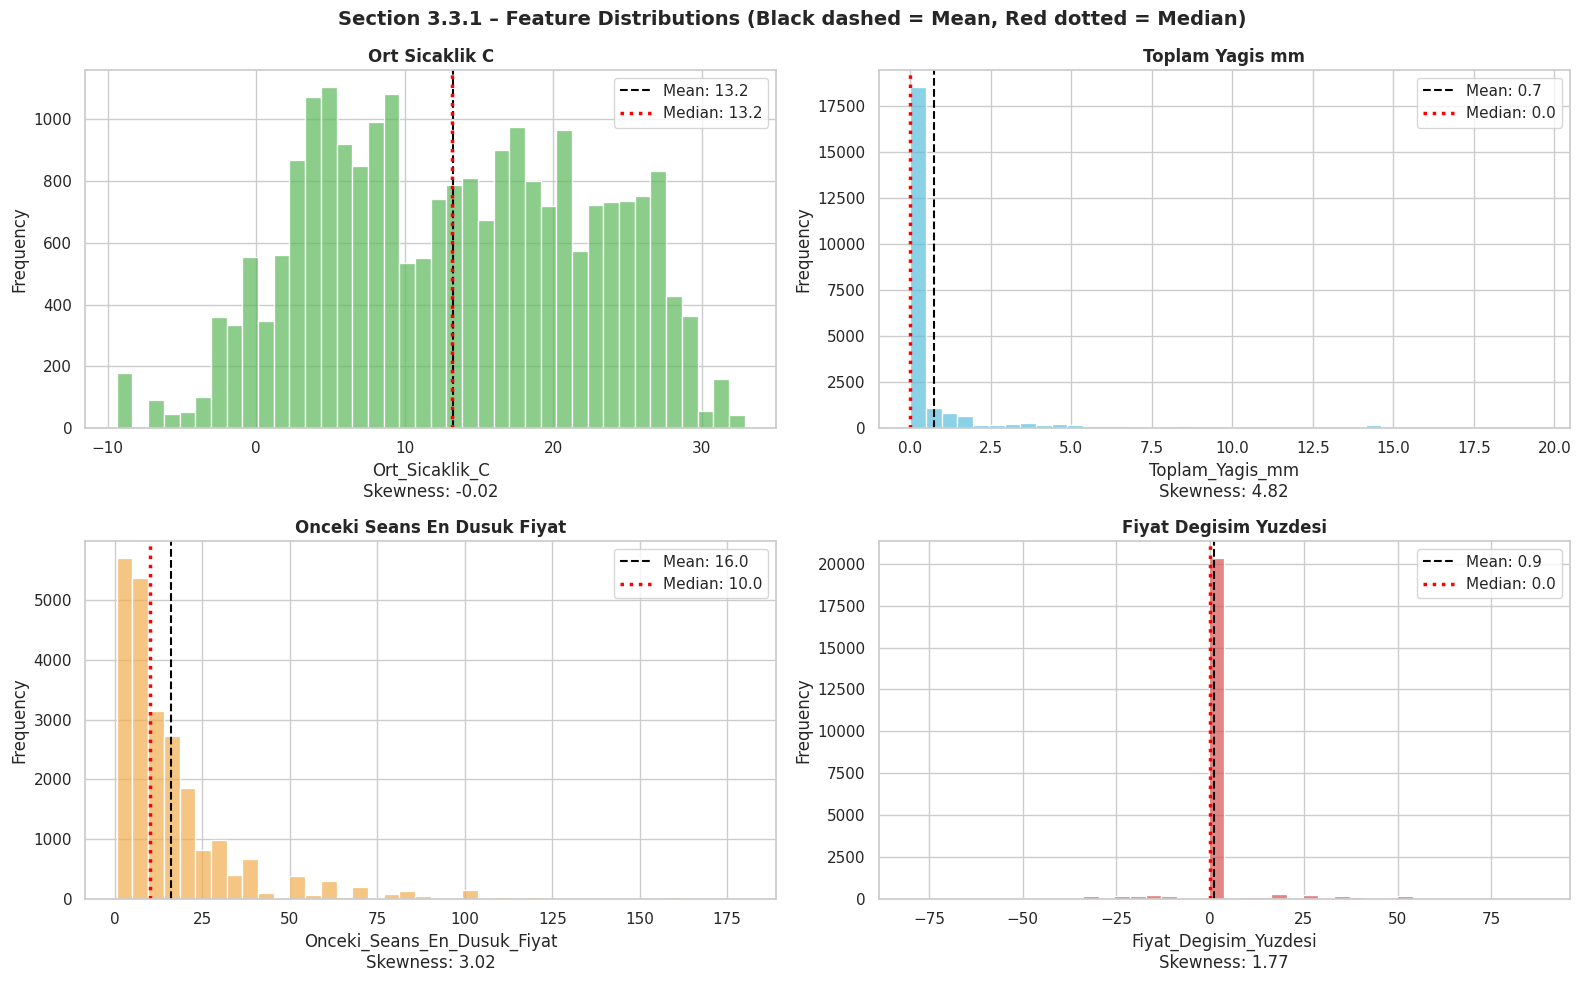

In [21]:
# —— 3.3.1 Distribution of All Numeric Features (Mean & Median) ——

numeric_features = ['Ort_Sicaklik_C', 'Toplam_Yagis_mm', 'Onceki_Seans_En_Dusuk_Fiyat', 'Fiyat_Degisim_Yuzdesi']
colors = ['#5cb85c', '#5bc0de', '#f0ad4e', '#d9534f'] # Farklı metrikler için renk paleti

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Section 3.3.1 – Feature Distributions (Black dashed = Mean, Red dotted = Median)', fontsize=14, fontweight='bold')
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    # Histogramı çizdir
    sns.histplot(df[col], kde=False, ax=axes[i], color=colors[i], bins=40, alpha=0.7)

    # İstatistikleri hesapla
    mean_val = df[col].mean()
    median_val = df[col].median()
    skew_val = df[col].skew()

    # Ortalama ve Medyan çizgilerini ekle
    axes[i].axvline(mean_val, color='black', linestyle='--', linewidth=1.5, label=f'Mean: {mean_val:.1f}')
    axes[i].axvline(median_val, color='red', linestyle=':', linewidth=2.5, label=f'Median: {median_val:.1f}')

    axes[i].set_title(col.replace('_', ' '), fontweight='bold')
    axes[i].set_xlabel(f"{col}\nSkewness: {skew_val:.2f}")
    axes[i].set_ylabel('Frequency')
    axes[i].legend()

plt.tight_layout()
plt.subplots_adjust(top=0.92) # Üst başlık için boşluk
plt.show()

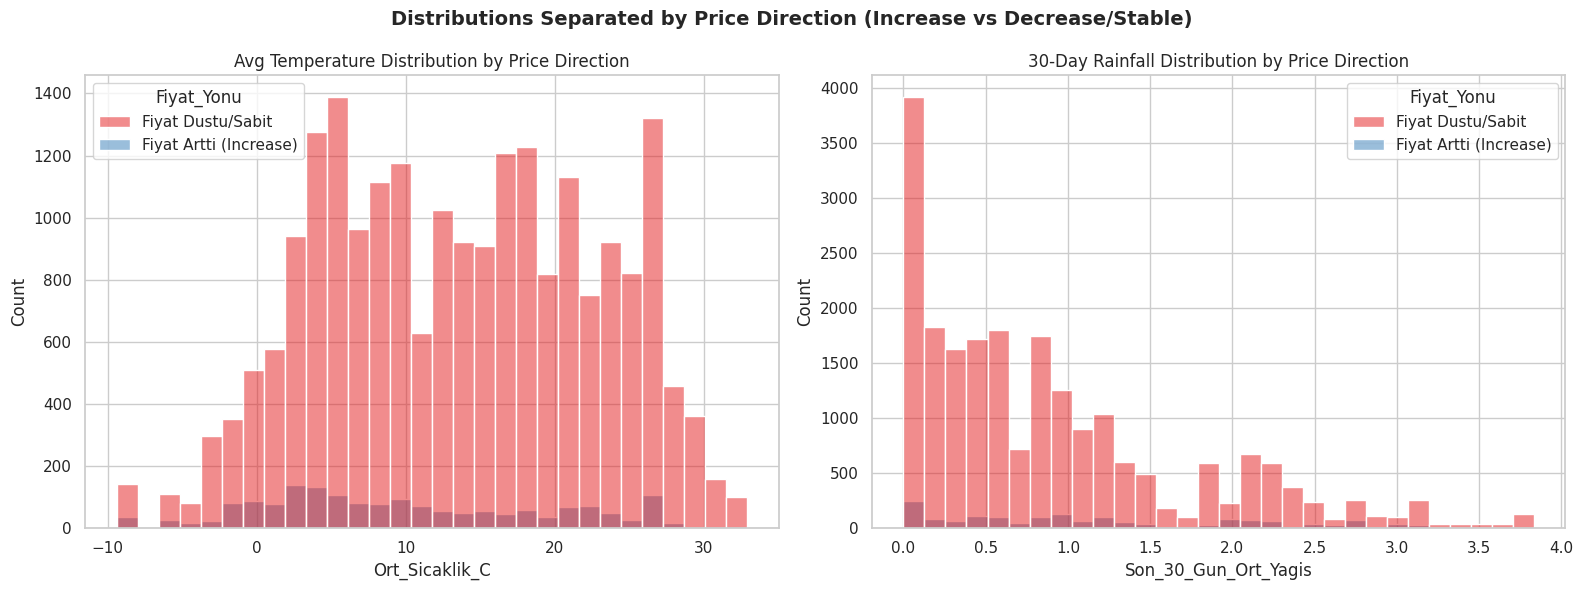

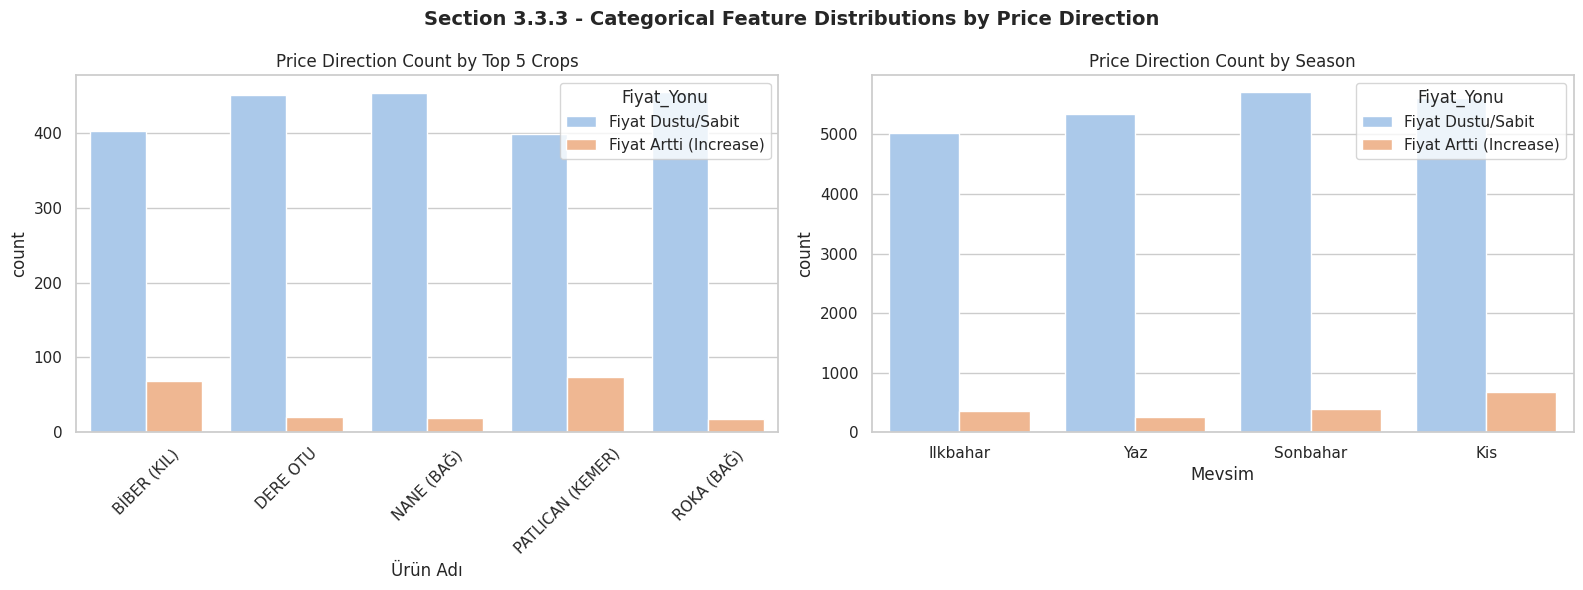

In [22]:
# —— Data Prep for Categorical EDA ——
# Görselleştirme için regresyon hedefini geçici bir sınıflandırma hedefine çeviriyoruz
df['Fiyat_Yonu'] = np.where(df['Fiyat_Degisim_Yuzdesi'] > 0, 'Fiyat Artti (Increase)', 'Fiyat Dustu/Sabit')

# Tarih üzerinden 'Mevsim' özelliğini türetiyoruz (Kategorik analiz için)
def get_season(month):
    if month in [3, 4, 5]: return 'Ilkbahar'
    elif month in [6, 7, 8]: return 'Yaz'
    elif month in [9, 10, 11]: return 'Sonbahar'
    else: return 'Kis'
df['Mevsim'] = df['Tarih'].dt.month.map(get_season)


# —— 3.3.2 Distributions Separated by Target Class (Price Direction) ——
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Distributions Separated by Price Direction (Increase vs Decrease/Stable)', fontweight='bold', fontsize=14)

# Sıcaklığa göre fiyat artışı
sns.histplot(data=df, x='Ort_Sicaklik_C', hue='Fiyat_Yonu', ax=axes[0], bins=30, alpha=0.5, multiple="layer", palette='Set1')
axes[0].set_title('Avg Temperature Distribution by Price Direction')

# Yağışa göre fiyat artışı
sns.histplot(data=df, x='Son_30_Gun_Ort_Yagis', hue='Fiyat_Yonu', ax=axes[1], bins=30, alpha=0.5, multiple="layer", palette='Set1')
axes[1].set_title('30-Day Rainfall Distribution by Price Direction')

plt.tight_layout()
plt.show()


# —— 3.3.3 Categorical Feature Distributions by Target Class ——
# Çok fazla ürün olduğu için grafik karışmasın diye sadece en popüler 5 ürünü alıyoruz
top_5_crops = df['Ürün Adı'].value_counts().nlargest(5).index
df_top5 = df[df['Ürün Adı'].isin(top_5_crops)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section 3.3.3 - Categorical Feature Distributions by Price Direction', fontweight='bold', fontsize=14)

# Ürün bazında fiyat artış/düşüş frekansı
sns.countplot(data=df_top5, x='Ürün Adı', hue='Fiyat_Yonu', ax=axes[0], palette='pastel')
axes[0].set_title('Price Direction Count by Top 5 Crops')
axes[0].tick_params(axis='x', rotation=45)

# Mevsime bazında fiyat artış/düşüş frekansı
sns.countplot(data=df, x='Mevsim', hue='Fiyat_Yonu', ax=axes[1], palette='pastel', order=['Ilkbahar', 'Yaz', 'Sonbahar', 'Kis'])
axes[1].set_title('Price Direction Count by Season')

plt.tight_layout()
plt.show()

### Section 3.4 – Relationships

#### 3.4.1 Correlation Heatmap
To understand linear relationships, we analyze the correlation between our stationary target variable (`Fiyat_Degisim_Yuzdesi`) and climate features.
*(Note: Since baseline prices and market dynamics differ wildly across crops, we isolate a staple crop—'DOMATES' (Tomato)—for a clear signal).*

Seçilen ürün için satır sayısı: 471


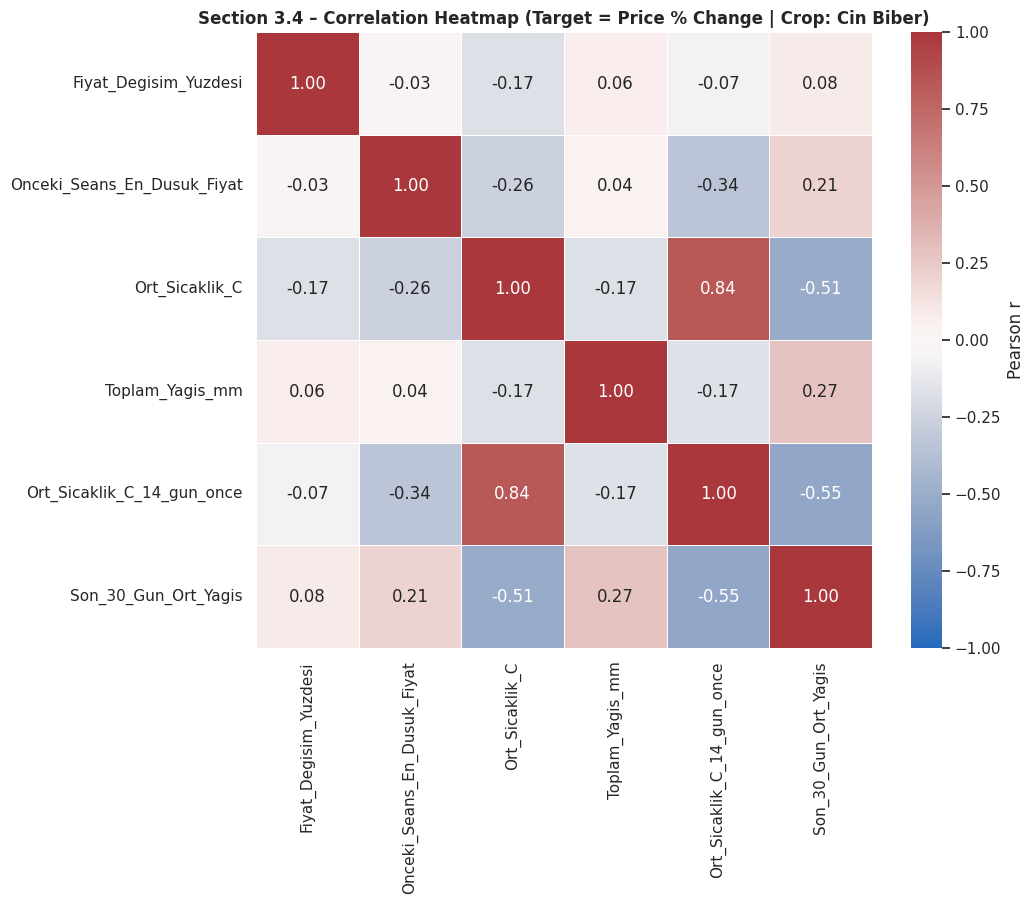


Feature correlations with Target (% Change) for Cin Biber:
Ort_Sicaklik_C                -0.172370
Son_30_Gun_Ort_Yagis           0.081618
Ort_Sicaklik_C_14_gun_once    -0.069090
Toplam_Yagis_mm                0.064462
Onceki_Seans_En_Dusuk_Fiyat   -0.033608
Name: Fiyat_Degisim_Yuzdesi, dtype: float64


In [23]:
# —— Section 3.4: Correlation Heatmap with Stationary Target ——

numeric_cols = [
    'Fiyat_Degisim_Yuzdesi', 'Onceki_Seans_En_Dusuk_Fiyat',
    'Ort_Sicaklik_C', 'Toplam_Yagis_mm',
    'Ort_Sicaklik_C_14_gun_once', 'Son_30_Gun_Ort_Yagis'
]

# ÇÖZÜM: Veri setinde kesinlikle var olan bir ürünü seçiyoruz ('BİBER (CİN)')
df_sample = df[df['Ürün Adı'] == 'BİBER (CİN)'].copy()

# Tablonun boş olup olmadığını kontrol edelim (Debugging)
print(f"Seçilen ürün için satır sayısı: {len(df_sample)}")

# Eğer satır sayısı 0'dan büyükse grafiği çizdir
if len(df_sample) > 0:
    corr_matrix = df_sample[numeric_cols].corr()

    plt.figure(figsize=(10, 8))
    sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="vlag", vmin=-1, vmax=1,
                square=True, linewidths=.5, cbar_kws={"label": "Pearson r"})
    plt.title("Section 3.4 – Correlation Heatmap (Target = Price % Change | Crop: Cin Biber)", fontweight='bold')
    plt.show()

    print("\nFeature correlations with Target (% Change) for Cin Biber:")
    print(corr_matrix['Fiyat_Degisim_Yuzdesi'].drop('Fiyat_Degisim_Yuzdesi').sort_values(key=abs, ascending=False))
else:
    print("HATA: Seçilen ürün bulunamadı. Lütfen ürün adını kontrol edin.")

#### 3.4.2 Interpretation of Low Pearson Correlations (The Non-Linearity Problem)

At first glance, the correlation heatmap shows very weak linear relationships (mostly between -0.20 and +0.20) between climate features and daily price percentage changes. This is highly expected in financial and agricultural time-series data for two reasons:

1. **Non-Linear Thresholds:** Pearson measures strictly linear relationships. However, agricultural economics is threshold-based. For example, a temperature drop from 30°C to 25°C does not impact yield, but a drop from 5°C to 0°C (frost) causes severe supply shocks and price spikes. Pearson correlation fails to capture these non-linear trigger points.
2. **Market Microstructure (Random Walk):** Daily percentage changes in wholesale markets often contain high levels of "white noise" and behave similarly to stock market returns, making linear prediction nearly impossible.

**Conclusion for Modeling:** Linear Regression will likely fail on this dataset. We must rely on non-linear, tree-based Machine Learning models (like Random Forest or XGBoost) capable of capturing complex conditional rules (e.g., `IF temp < 0 AND season == Winter THEN price_spike`).

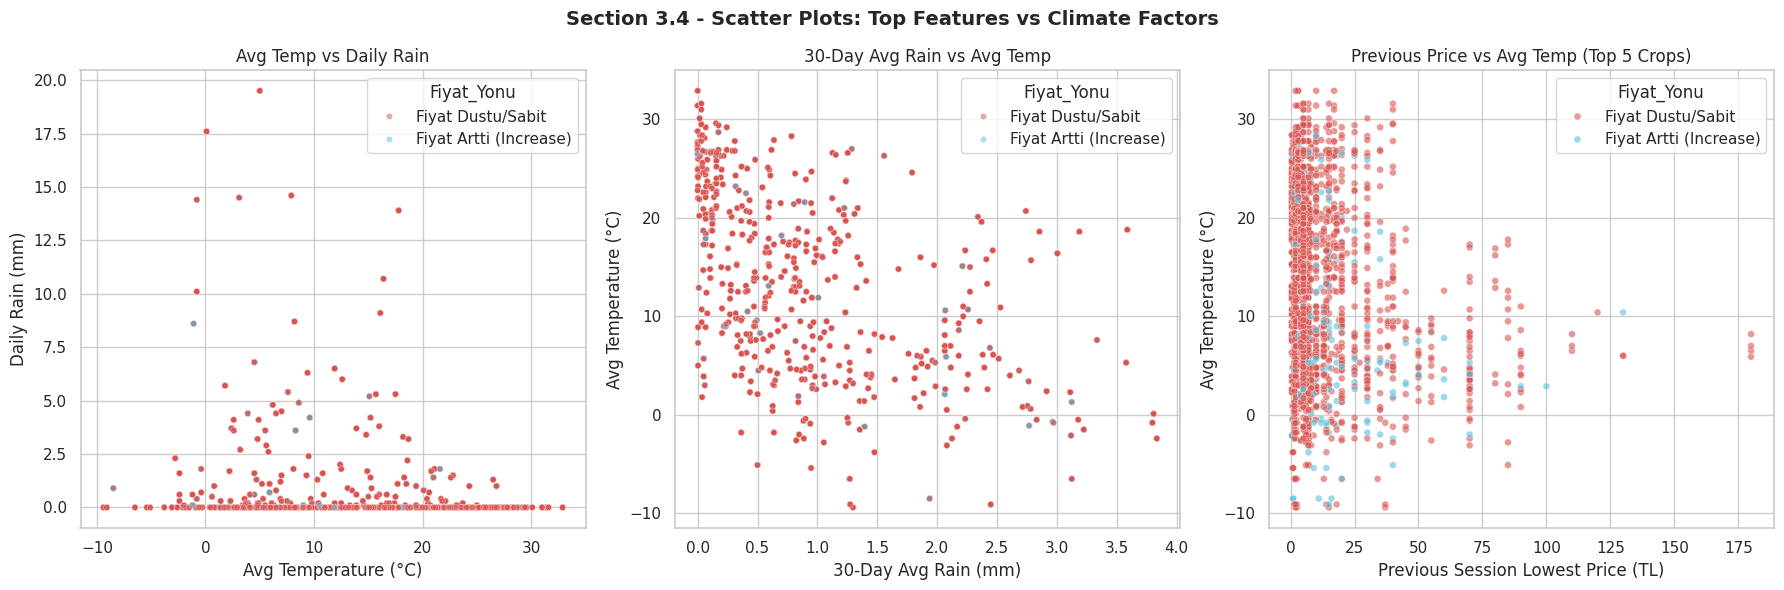

In [24]:
# —— Section 3.4.3- Scatter Plots: Top Features vs Climate Factors ——

# Fiyat_Yonu (Price Direction) sütununu önceki hücrede oluşturmuştuk, tekrar garantileyelim
if 'Fiyat_Yonu' not in df.columns:
    df['Fiyat_Yonu'] = np.where(df['Fiyat_Degisim_Yuzdesi'] > 0, 'Fiyat Artti (Increase)', 'Fiyat Dustu/Sabit')

# İlk 5 ürünü filtreleyelim (Fiyat skalaları çok farklı olduğu için grafiği bozmamak adına)
top_5_crops = df['Ürün Adı'].value_counts().nlargest(5).index
df_top5 = df[df['Ürün Adı'].isin(top_5_crops)]

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle('Section 3.4 - Scatter Plots: Top Features vs Climate Factors', fontweight='bold', fontsize=14)

# 1. Ortalama Sıcaklık vs Günlük Yağış (Sıcaklık ve yağışın fiyat artışına ortak etkisi)
sns.scatterplot(data=df, x='Ort_Sicaklik_C', y='Toplam_Yagis_mm', hue='Fiyat_Yonu',
                alpha=0.5, ax=axes[0], palette=['#d9534f', '#5bc0de'], s=20)
axes[0].set_title('Avg Temp vs Daily Rain')
axes[0].set_xlabel('Avg Temperature (°C)')
axes[0].set_ylabel('Daily Rain (mm)')

# 2. 30 Günlük Yağış vs Ortalama Sıcaklık (Uzun dönemli kuraklık/yağış etkisi)
sns.scatterplot(data=df, x='Son_30_Gun_Ort_Yagis', y='Ort_Sicaklik_C', hue='Fiyat_Yonu',
                alpha=0.5, ax=axes[1], palette=['#d9534f', '#5bc0de'], s=20)
axes[1].set_title('30-Day Avg Rain vs Avg Temp')
axes[1].set_xlabel('30-Day Avg Rain (mm)')
axes[1].set_ylabel('Avg Temperature (°C)')

# 3. Önceki Seans Fiyatı vs Ortalama Sıcaklık (Sadece Top 5 ürün için)
sns.scatterplot(data=df_top5, x='Onceki_Seans_En_Dusuk_Fiyat', y='Ort_Sicaklik_C', hue='Fiyat_Yonu',
                alpha=0.6, ax=axes[2], palette=['#d9534f', '#5bc0de'], s=25)
axes[2].set_title('Previous Price vs Avg Temp (Top 5 Crops)')
axes[2].set_xlabel('Previous Session Lowest Price (TL)')
axes[2].set_ylabel('Avg Temperature (°C)')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

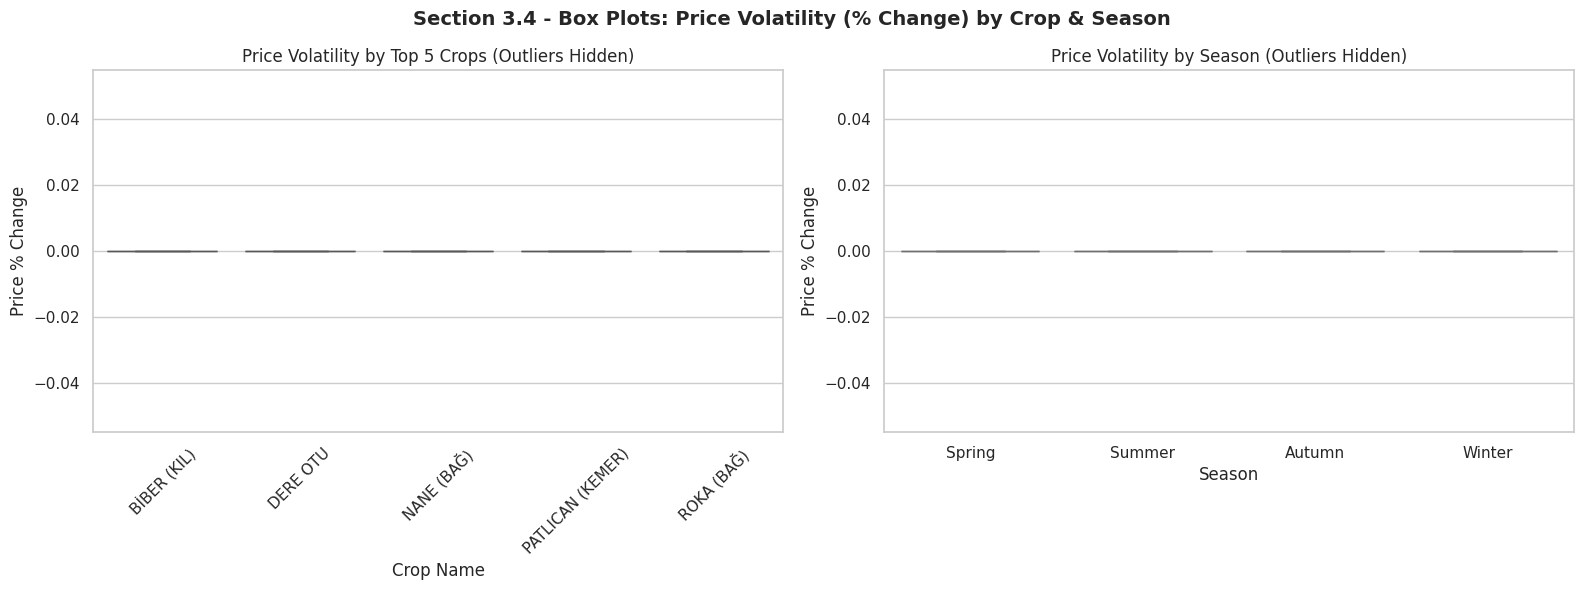

In [26]:
# —— Section 3.4.4 - Box Plots: Price Volatility by City (Crop) & Season ——

# ÇÖZÜM: 'if' kontrolünü kaldırdık ve verileri zorunlu olarak İngilizceye çeviriyoruz
def get_season_eng(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    elif month in [9, 10, 11]: return 'Autumn'
    else: return 'Winter'

df['Mevsim'] = df['Tarih'].dt.month.map(get_season_eng)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section 3.4 - Box Plots: Price Volatility (% Change) by Crop & Season', fontweight='bold', fontsize=14)

# 1. Ürünlere Göre Fiyat Değişim Yüzdesi
# Kutu grafikleri aykırı değerlerden (outliers) çok etkilenir.
# Kutuları (IQR) net görebilmek için y eksenini -30% ile +30% arasına sabitliyoruz (showfliers=False)
sns.boxplot(data=df_top5, x='Ürün Adı', y='Fiyat_Degisim_Yuzdesi', ax=axes[0], palette='Set2', showfliers=False)
axes[0].set_title('Price Volatility by Top 5 Crops (Outliers Hidden)')
axes[0].set_xlabel('Crop Name')
axes[0].set_ylabel('Price % Change')
axes[0].tick_params(axis='x', rotation=45)

# 2. Mevsimlere Göre Fiyat Değişim Yüzdesi
sns.boxplot(data=df, x='Mevsim', y='Fiyat_Degisim_Yuzdesi', ax=axes[1], palette='pastel',
            order=['Spring', 'Summer', 'Autumn', 'Winter'], showfliers=False)
axes[1].set_title('Price Volatility by Season (Outliers Hidden)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Price % Change')

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

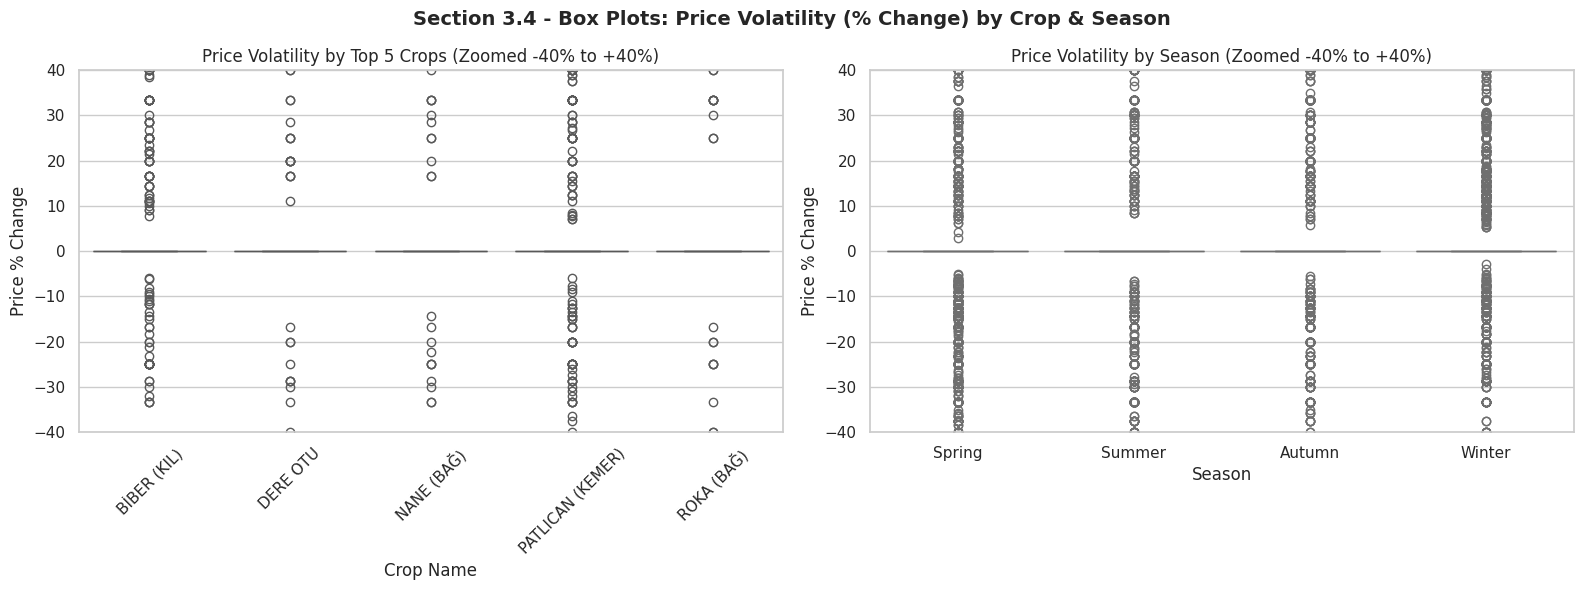

In [27]:
# —— Section 3.4.4 - Box Plots: Price Volatility by City (Crop) & Season ——

# 'Mevsim' sütunu İngilizce olarak oluşturuluyor
def get_season_eng(month):
    if month in [3, 4, 5]: return 'Spring'
    elif month in [6, 7, 8]: return 'Summer'
    elif month in [9, 10, 11]: return 'Autumn'
    else: return 'Winter'

df['Mevsim'] = df['Tarih'].dt.month.map(get_season_eng)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Section 3.4 - Box Plots: Price Volatility (% Change) by Crop & Season', fontweight='bold', fontsize=14)

# 1. Ürünlere Göre Fiyat Değişim Yüzdesi
# showfliers=True yaptık ki gerçek piyasa hareketleri (aykırı değerler) geri gelsin.
# set_ylim ile grafiğe zoom yapıyoruz.
sns.boxplot(data=df_top5, x='Ürün Adı', y='Fiyat_Degisim_Yuzdesi', ax=axes[0], palette='Set2', showfliers=True)
axes[0].set_title('Price Volatility by Top 5 Crops (Zoomed -40% to +40%)')
axes[0].set_xlabel('Crop Name')
axes[0].set_ylabel('Price % Change')
axes[0].set_ylim(-40, 40) # Y eksenini sabitledik
axes[0].tick_params(axis='x', rotation=45)

# 2. Mevsimlere Göre Fiyat Değişim Yüzdesi
sns.boxplot(data=df, x='Mevsim', y='Fiyat_Degisim_Yuzdesi', ax=axes[1], palette='pastel',
            order=['Spring', 'Summer', 'Autumn', 'Winter'], showfliers=True)
axes[1].set_title('Price Volatility by Season (Zoomed -40% to +40%)')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('Price % Change')
axes[1].set_ylim(-40, 40) # Y eksenini sabitledik

plt.tight_layout()
plt.subplots_adjust(top=0.88)
plt.show()

## Section 4 – Feature Engineering & Data Quality

### 4.1 Overview of Categorical Encoding & Prep

| Step | What We Did | Why |
| :--- | :--- | :--- |
| **Date Features** | Extracted `Ay` (Month) from `Tarih` | Captures systematic seasonal variations independent of daily temperature. |
| **Encoding - Crop Name** | Frequency Encoding & Grouping (`Urun_Grup`) | High cardinality (many crop types) makes standard One-Hot Encoding inefficient. We grouped the top 10 crops and labeled the rest as 'DIGER' (Other). |
| **Categorical Encoding** | `pd.get_dummies` on grouped crops | Converts text categories into numeric boolean features for tree-based ML models. |

In [ ]:
# —— Feature Engineering: Date Extraction & Encoding ——

df_final = df.copy()

# Extract Month for seasonality
df_final['Ay'] = df_final['Tarih'].dt.month

# Frequency Encoding for Crop Names
crop_freq = df_final['Ürün Adı'].value_counts(normalize=True)
df_final['Urun_Frekans_Kodu'] = df_final['Ürün Adı'].map(crop_freq)

# Keep top 10 crops, label others as 'DIGER' to reduce noise
top_crops = df_final['Ürün Adı'].value_counts().nlargest(10).index
df_final['Urun_Grup'] = np.where(df_final['Ürün Adı'].isin(top_crops), df_final['Ürün Adı'], 'DIGER')

# One-Hot Encode the grouped crops
df_encoded = pd.get_dummies(df_final, columns=['Urun_Grup'], drop_first=True)

print(f"Encoded dataset shape: {df_encoded.shape}")

In [ ]:
# —— Final Dataset Summary ——

print("-" * 60)
print("FINAL ML-READY DATASET SUMMARY")
print("-" * 60)
print(f"Rows          : {df_encoded.shape[0]}")
print(f"Columns       : {df_encoded.shape[1]}")
print(f"Date Range    : {df_encoded['Tarih'].min().date()} to {df_encoded['Tarih'].max().date()}")
print(f"Unique Crops  : {df_final['Ürün Adı'].nunique()}")
print(f"Missing Values: {df_encoded.isna().sum().sum()}")
print("-" * 60)

# Reorder columns to put Target at the end for easy viewing
target_col = 'Fiyat_Degisim_Yuzdesi'
cols = [c for c in df_encoded.columns if c != target_col] + [target_col]
df_encoded = df_encoded[cols]

print("\nFirst 3 rows:")
display(df_encoded.head(3))

print("\nLast 3 rows:")
display(df_encoded.tail(3))